<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Transfer_Learning_con_CycleGAN_(Conversi%C3%B3n_de_im%C3%A1genes_Manzana_%E2%86%94_Naranja)_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transfer Learning con CycleGAN (Conversión de imágenes Manzana ↔ Naranja)-Armando Chacón Terrazas**

Entrenar y evaluar un modelo CycleGAN con transferencia de aprendizaje basada en VGG16 para la conversión de imágenes entre los dominios de manzanas y naranjas.
El propósito es comprender la arquitectura de una red generativa adversarial cíclica (CycleGAN), así como las estrategias de transfer learning y la adaptación a nuevos dominios de imágenes.

**Descripción General**

Utilizando el programa base TransferLearningCycleGAN_v2.ipynb (ya proporcionado), deberán:

Entrenar el modelo modificando el conjunto de datos para usar apple2orange en lugar de horse2zebra.
Analizar los resultados de la conversión manzanas → naranjas y naranjas → manzanas.
Documentar el proceso de entrenamiento, los resultados obtenidos y las observaciones más relevantes.
Requisitos del entorno

El entrenamiento del modelo requiere una GPU para completarse en un tiempo razonable (~2 horas).
Por ello, se sugiere realizar el entrenamiento en alguno de los siguientes entornos:

Servidor del Instituto de Ingeniería y Tecnología (IIT-UACJ)
Verifiquen la disponibilidad del recurso compartido antes de iniciar el entrenamiento.
Alternativas en la nube (si no usan el servidor):
Google Colab+
Kaggle Notebooks
Keras Cloud (opcional)
Datos a utilizar

El conjunto de datos apple2orange puede descargarse del sitio oficial de CycleGAN Datasets:

Liga: https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/
Archivo a descargar: apple2orange.zip

Aunque no es necesario, si lo desea, puede descomprimir el archivo para tener las imágenes en su disco duro y cargarlas desde allí al ejecutar su programa. Asegúrarse de mantener la estructura esperada por TensorFlow Datasets:

apple2orange/

├── trainA/   # imágenes de manzanas

├── trainB/   # imágenes de naranjas

├── testA/    # imágenes de manzanas (prueba)

└── testB/    # imágenes de naranjas (prueba)



**Instrucciones principales**

Cargar y adaptar el notebook TransferLearningCycleGAN_v2.ipynb.
Sustituir en el código el dataset horse2zebra por apple2orange.
     Dataset, dataset_info = tfds.load(‘cycle_gan/apple2orange’, with_info=True, as_supervised=True)

Ejecutar el entrenamiento completo del modelo.
El entrenamiento puede tomar entre 1.5 y 2 horas en GPU.
Asegúrense de monitorear la memoria GPU para evitar errores por saturación.
Guardar el modelo entrenado al finalizar:
     gen.save("generator_apple2orange.keras")

Probar el modelo cargando una imagen nueva (por ejemplo, una manzana) y mostrar su conversión a naranja.
Repetir el proceso inverso: convertir una naranja a manzana.
Incluir las imágenes de ejemplo en el reporte final.

# **1. Configuración de Entorno y Datos**

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os

# 1. Conectamos Colab con Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Configuramos la GPU para que no se sature
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU lista y optimizada.")
    except RuntimeError as e:
        print(f"❌ Error en GPU: {e}")

# 3. Descomprimimos el archivo ZIP en la memoria local (/content/)
# Esto evita cuellos de botella al leer miles de imágenes.
zip_path = "/content/drive/MyDrive/UACJ/Redes Neuronales Profundas/Colab_Datasets/apple2orange.zip"
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    !unzip -q "{zip_path}" -d "{extract_path}"
    print("✅ Dataset listo en memoria local.")

# Definimos la ruta de las carpetas según estructura
base_dir = "/content/dataset/apple2orange"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GPU lista y optimizada.


# **2. El Procesador de Imágenes**

In [ ]:
# Parámetros del entrenamiento
batch_size = 16    # Cuántas fotos procesamos a la vez
img_size = 128     # Tamaño final de la imagen
big_img_size = 160 # Tamaño para recortes y variedad
LR = 0.00012       # Velocidad de aprendizaje (Learning Rate)
act_name = 'gelu'  # Tipo de "cerebro" para las neuronas

def _process_img(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3) # Imagen a color
    img = tf.image.resize(img, (big_img_size, big_img_size))
    img = (img / 127.5) - 1.0 # Normalizamos los colores de -1 a 1
    return img

def load_ds(folder):
    path = os.path.join(base_dir, folder)
    files = tf.data.Dataset.list_files(path + "/*.jpg")
    return files.map(_process_img, num_parallel_calls=tf.data.AUTOTUNE).cache()

# Cargamos 4 carpetas (trainA, trainB, testA, testB)
train_a_raw = load_ds('trainA') # Manzanas
train_b_raw = load_ds('trainB') # Naranjas

# Preparamos los paquetes de datos
ds_train_a = train_a_raw.shuffle(1000).batch(batch_size)
ds_train_b = train_b_raw.shuffle(1000).batch(batch_size)

# Convertimos a Tensores rápidos para la GPU
x_train_sets = [
    tf.concat([img for img in ds_train_a], axis=0),
    tf.concat([img for img in ds_train_b], axis=0),
]
print(f"✅ Datos listos. Manzanas: {len(x_train_sets[0])}, Naranjas: {len(x_train_sets[1])}")

✅ Datos listos. Manzanas: 995, Naranjas: 1019


# **3. Transfer Learning con VGG16**

In [ ]:
# 1. Cargamos el cerebro experto VGG16 (Transfer Learning)
vgg = tf.keras.applications.VGG16(input_shape=(img_size, img_size, 3), include_top=False)
vgg_layers = ['block2_conv2', 'block3_conv3', 'block4_conv3', 'block5_conv1', 'block5_pool']
base_model = tf.keras.models.Model(vgg.input, [vgg.get_layer(n).output for n in vgg_layers])
base_model.trainable = False # No entrenamos VGG

# --- Funciones para construir el Generador y el Discriminador ---
def act(x):
    x = layers.LayerNormalization()(x)
    return layers.Activation(act_name)(x)

def conv_with_cmd(x_img, x_cmd, filters):
    # Esta capa mezcla la imagen con la "orden" de transformación
    c = layers.Dense(filters)(x_cmd)
    c = layers.Activation('sigmoid')(c)
    c = layers.Reshape((1, 1, filters))(c)
    img = layers.Conv2D(filters, 3, padding='same')(x_img)
    return act(img) * c

def create_gen():
    x_in = layers.Input(shape=(img_size, img_size, 3))
    [x64, x32, x16, x8, x4] = base_model(x_in) # Vemos la imagen a través de VGG

    # El "cuello de botella" donde ocurre la magia
    bottleneck = layers.GlobalMaxPool2D()(layers.Conv2D(256, 3, padding='same')(x4))
    x_cmd = layers.Activation(act_name)(layers.BatchNormalization()(layers.Dense(128)(bottleneck)))

    # Reconstruimos la imagen transformada
    x = conv_with_cmd(x4, x_cmd, 512)
    for (feat, f) in [(x8, 512), (x16, 384), (x32, 256), (x64, 256), (x_in, 256)]:
        x = layers.UpSampling2D(2)(x)
        x = layers.Concatenate()([x, feat])
        x = conv_with_cmd(x, x_cmd, f)

    out = layers.Activation('tanh')(layers.Conv2D(3, 3, padding='same')(x))
    return tf.keras.models.Model(x_in, out)

def create_dis():
    x_in = layers.Input(shape=(img_size, img_size, 3))
    [_, _, _, x8, x4] = base_model(x_in)
    x = layers.GlobalMaxPool2D()(act(layers.Conv2D(512, 3, padding='same')(layers.Concatenate()([layers.MaxPool2D()(x8), x4]))))
    out = layers.Dense(4, activation='softmax')(layers.Dense(384)(x))
    return tf.keras.models.Model(x_in, out)

gen = create_gen()
dis = create_dis()
print("✅ Modelos creados correctamente.")

✅ Modelos creados correctamente.


# **4. El Artista (Generador) y el Crítico (Discriminador)**

In [ ]:
opt_gen = tf.keras.optimizers.AdamW(learning_rate=LR)
opt_dis = tf.keras.optimizers.AdamW(learning_rate=LR)

# Etiquetas para el crítico: Falso (0,1), Real (2,3)
y_f_a, y_f_b = np.zeros(batch_size), np.ones(batch_size)
y_t_a, y_t_b = np.full(batch_size, 2), np.full(batch_size, 3)

def _rand(data):
    idx = np.random.choice(range(len(data)), batch_size, replace=False)
    x = tf.image.resize(tf.gather(data, idx), (img_size, img_size))
    return tf.image.random_flip_left_right(x)

@tf.function
def _train_dis(x, y):
    with tf.GradientTape() as t:
        loss = tf.reduce_mean(tf.losses.sparse_categorical_crossentropy(y, dis(x)))
    opt_dis.apply_gradients(zip(t.gradient(loss, dis.trainable_variables), dis.trainable_variables))
    return loss

def train_dis():
    xa, xb = _rand(x_train_sets[0]), _rand(x_train_sets[1])
    # Entrenamos con fotos reales y con las "pinturas" falsas del artista
    l_a = _train_dis(xa, y_t_a) + _train_dis(gen(xb), y_f_a)
    l_b = _train_dis(xb, y_t_b) + _train_dis(gen(xa), y_f_b)
    return float(l_a), float(l_b)

@tf.function
def _train_gen(x_real, y_target):
    with tf.GradientTape() as t:
        x_fake = gen(x_real)
        # 1. ¿Logramos engañar al crítico?
        loss_adv = tf.reduce_mean(tf.losses.sparse_categorical_crossentropy(y_target, dis(x_fake)))
        # 2. Consistencia de Ciclo: ¿Si regreso a la fruta original se parece?
        loss_cyc = tf.reduce_mean(tf.losses.mse(x_real, gen(x_fake))) * 10 # Lambda = 10
        loss = loss_adv + loss_cyc
    opt_gen.apply_gradients(zip(t.gradient(loss, gen.trainable_variables), gen.trainable_variables))
    return loss

def train_gen():
    xa, xb = _rand(x_train_sets[0]), _rand(x_train_sets[1])
    return float(_train_gen(xa, y_t_b)), float(_train_gen(xb, y_t_a))

def preview():
    xa, xb = _rand(x_train_sets[0]), _rand(x_train_sets[1])
    pred = gen.predict(xa[:5], verbose=0)
    plt.figure(figsize=(10, 4))
    for i in range(5):
        plt.subplot(2, 5, i+1); plt.imshow((xa[i]+1)/2); plt.axis('off')
        plt.subplot(2, 5, i+6); plt.imshow((pred[i]+1)/2); plt.axis('off')
    plt.show()

# **5. Ejecución del Entrenamiento y Guardado Final**

  0%|          | 0/50 [00:00<?, ?it/s]

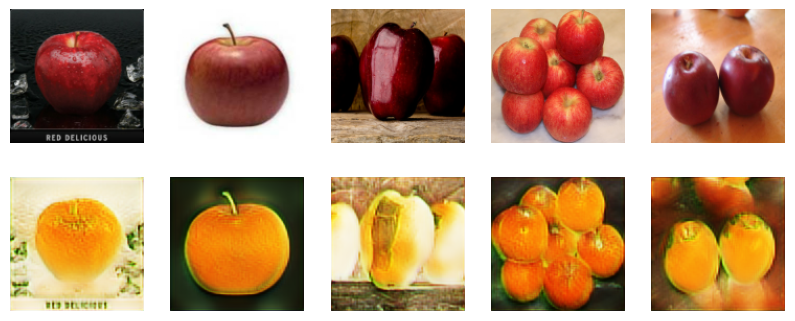

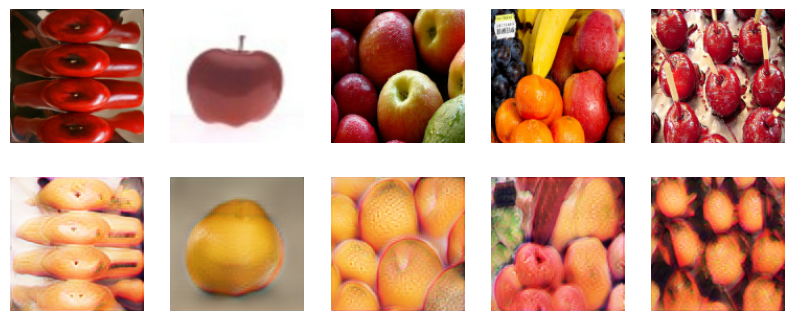

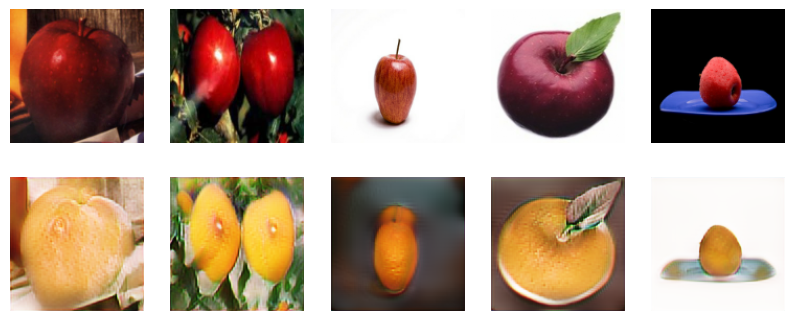

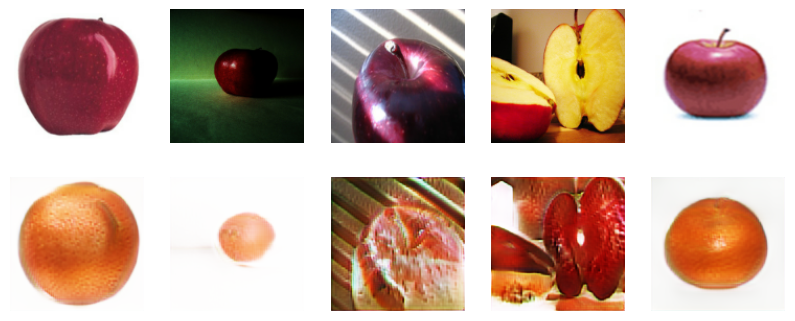

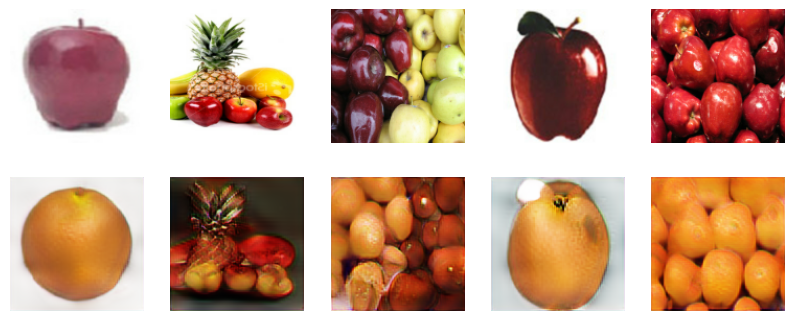

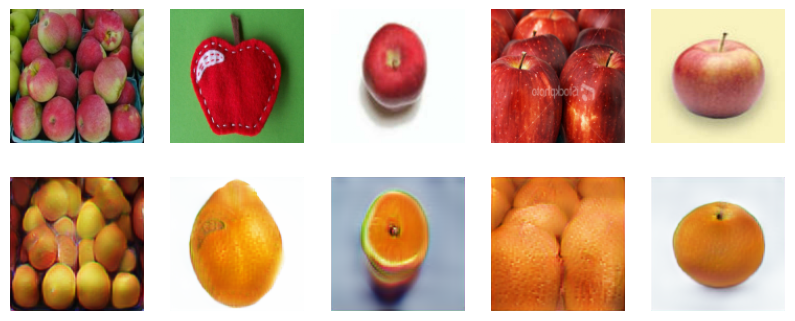

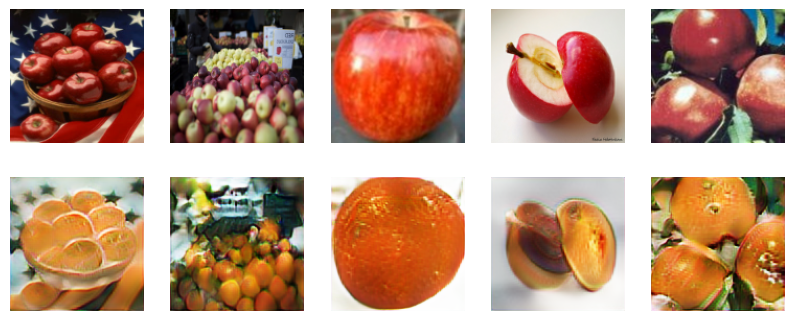

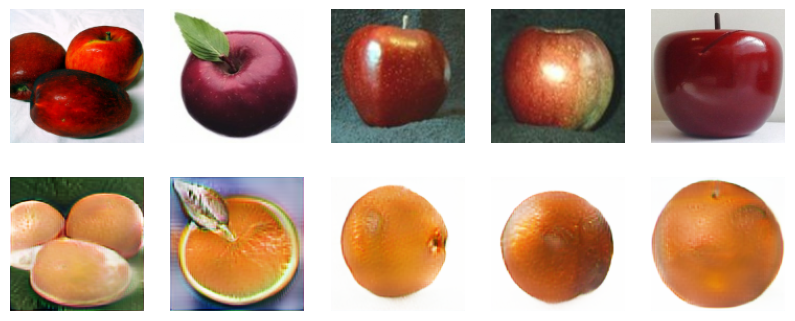

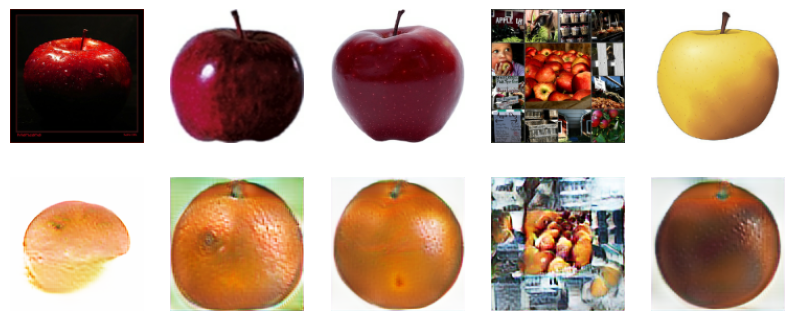

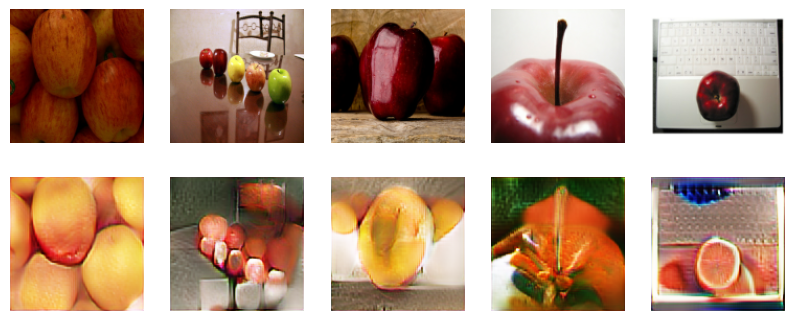

✅ Modelo guardado como generator_apple2orange.keras


In [ ]:
def go(epochs=50):
    for i in trange(epochs):
        for _ in range(100): # 100 pasos por época
            train_dis()
            train_gen()

        if i % 5 == 0:
            preview() # Ver progreso cada 5 épocas

        # Reducimos un poco la velocidad de aprendizaje (Decay)
        opt_dis.learning_rate.assign(opt_dis.learning_rate * 0.98)
        opt_gen.learning_rate.assign(opt_gen.learning_rate * 0.98)

# --- INICIAR EL ENTRENAMIENTO ---
go()

# --- GUARDAR RESULTADOS ---
gen.save("generator_apple2orange.keras")
print("✅ Modelo guardado como generator_apple2orange.keras")